# Experimental coding 4 — Convergence speed, and verifying the comparison is fair

**BMDS2114 Machine Learning — Group G1**

Context-Aware Notification Engine (CANE): a reinforcement-learning approach to fatigue-aware push-notification pacing for user-engagement optimisation.

---

## 1. Purpose of this experiment

Two questions that are easy to skip and expensive to get wrong.

**Convergence.** Final reward says which algorithm ends up best. It says nothing about which gets there first, and for a system trained against real users those are different questions -- an agent needing three times the episodes spends three times as long sending badly timed notifications to real people.

**Verification.** The four algorithms were developed in separate notebooks by different team members. A four-way comparison is only meaningful if all four were evaluated on identical episodes under an identical protocol. That is checked here rather than assumed.


## 2. Setup: libraries, tools, and where the code lives

All studies import the shared `cane` package -- the environment, evaluation harness and agents, extracted verbatim from the four notebooks and checked for bit-for-bit parity against them. They run on **Python 3.11 / PyTorch 2.13 (CPU)**, with `numpy` and `pandas` for the recorded results and `matplotlib` for figures. Each study parallelises across cores via `--jobs`; torch is pinned to one thread per worker so the workers do not contend.

`tools/render_check.py` executes a Streamlit page against a stub `streamlit` module and calls `.to_dict()` on every chart it builds. Altair validates a specification only at serialisation time, so a chart that constructs without error can still fail in the browser; this catches that from the command line.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "artifacts").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
ART = ROOT / "artifacts"

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)

import sys
print("reading recorded results from:", ART)
print("python", sys.version.split()[0],
      "| pandas", pd.__version__, "| numpy", np.__version__)


reading recorded results from: D:\Uni Assignments\ML\artifacts
python 3.11.15 | pandas 3.0.5 | numpy 2.4.6


### 2.1 The source that was executed

These files produced every number in this notebook. They are run from the repository root and write their output into `artifacts/`.

In [2]:
SOURCES = [
    "tools/learning_curves.py",
    "tools/check_results.py",
    "tools/parity_check.py",
    "tools/render_check.py"
]

for _p in SOURCES:
    _f = ROOT / _p
    if _f.is_file():
        _n = len(_f.read_text(encoding='utf-8').splitlines())
        print(f'{_p:38} {_n:>5} lines')
    else:
        print(f'{_p:38}   NOT FOUND')


tools/learning_curves.py                 219 lines
tools/check_results.py                   131 lines
tools/parity_check.py                    103 lines
tools/render_check.py                    192 lines


## 3. Parameter settings and configuration

Shared across every study, so results stay comparable:

| Setting | Value |
|---|---|
| Held-out evaluation episodes | seeds 900,000-900,199 (200) |
| Default training budget | 600 episodes (~100,800 steps) |
| Episode length | 168 steps (one week, hourly) |
| Actions | Hold, Engagement Nudge, Incentive Nudge |
| Archetypes | OfficeWorker, NightOwlStudent, NightShiftWorker, NormalStudent, Housewife |
| Break-even click rate | 0.340 |

**Converged** is defined as the first checkpoint reaching 90% of that agent's *own* final reward and never dropping back. Measuring against each agent's own ceiling rather than a shared reward level is deliberate: a shared threshold flatters whichever algorithm scores highest and says nothing about speed.


## 4. Learning curves under both configurations

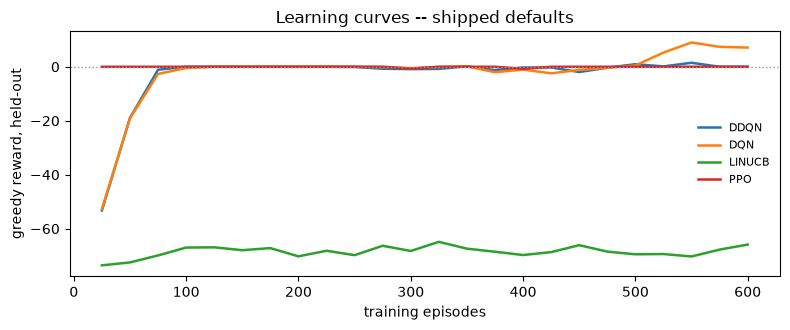

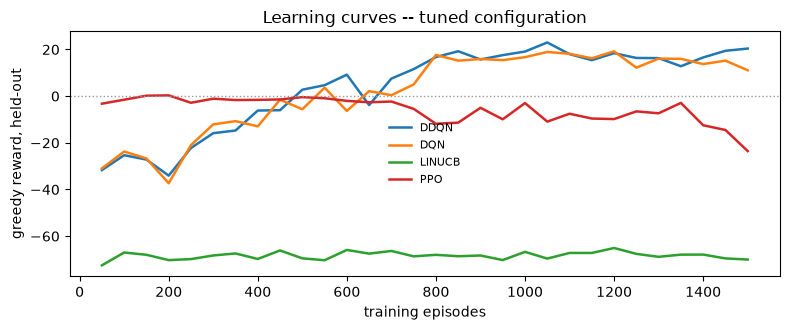

In [3]:
for suffix, label in [('', 'shipped defaults'),
                      ('_tuned', 'tuned configuration')]:
    f = ART / ('learning_curves' + suffix + '.csv')
    if not f.is_file():
        print(label, '-- not present')
        continue
    c = pd.read_csv(f)
    c['agent'] = c['agent'].str.upper()
    fig, ax = plt.subplots(figsize=(8, 3.4))
    for ag, d in c.groupby('agent'):
        m = d.groupby('episode')['reward'].mean()
        ax.plot(m.index, m.values, lw=1.8, label=ag)
    ax.axhline(0, color='#999999', ls=':', lw=1)
    ax.set_xlabel('training episodes')
    ax.set_ylabel('greedy reward, held-out')
    ax.set_title('Learning curves -- ' + label)
    ax.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

## 5. Episodes to converge

In [4]:
for suffix, label in [('', 'shipped defaults'),
                      ('_tuned', 'tuned configuration')]:
    f = ART / ('convergence' + suffix + '.csv')
    if not f.is_file():
        continue
    v = pd.read_csv(f)
    v['agent'] = v['agent'].str.upper()
    eff = (v.dropna(subset=['converged_at'])
            .groupby('agent')['converged_at']
            .agg(['mean', 'count'])
            .rename(columns={'mean': 'episodes to converge',
                             'count': 'archetypes that converged'}))
    print(label)
    print(eff.round(0).to_string() if len(eff)
          else '   nothing converged')
    print()
print('An agent missing from a table never rose above zero on any')
print('archetype, so it has no ceiling to converge to. Reporting a')
print('number for it would invent one.')

shipped defaults
       episodes to converge  archetypes that converged
agent                                                 
DQN                   550.0                          1

tuned configuration
       episodes to converge  archetypes that converged
agent                                                 
DDQN                 1450.0                          4
DQN                  1250.0                          4

An agent missing from a table never rose above zero on any
archetype, so it has no ceiling to converge to. Reporting a
number for it would invent one.


## 6. Verification: do all four notebooks describe one experiment?

In [5]:
files = {'LinUCB': ROOT / 'Code' / 'results' / 'linucb_results.csv',
         'DDQN':   ROOT / 'Code' / 'results' / 'ddqn_results.csv',
         'PPO':    ROOT / 'Code' / 'results' / 'ppo_results.csv',
         'DQN':    ROOT / 'DQN' / 'results' / 'dqn_results.csv'}
BASE = ['Fixed-18:00', 'Random']
key = ['archetype', 'agent', 'seed']
num = ['reward_mean', 'ctr', 'sends_per_episode', 'optout_rate']
ref_name, ref = None, None
for name, path in files.items():
    if not path.is_file():
        print(name, 'MISSING')
        continue
    d = pd.read_csv(path)
    b = (d[d['agent'].isin(BASE)].sort_values(key)
          .reset_index(drop=True))
    if ref is None:
        ref_name, ref = name, b
        print('reference:', name, '--', len(b), 'baseline rows')
        continue
    delta = float((b[num] - ref[num]).abs().max().max())
    print(f'{ref_name:7} vs {name:7} max |delta| = {delta:g}',
          ' ok' if delta < 1e-9 else '  MISMATCH')
print()
print('The two baselines are deterministic given the shared')
print('evaluation protocol. If they agree across all four files,')
print('the learners were scored on identical held-out episodes and')
print('the four-way comparison is like-for-like.')

reference: LinUCB -- 10 baseline rows
LinUCB  vs DDQN    max |delta| = 0  ok
LinUCB  vs PPO     max |delta| = 0  ok
LinUCB  vs DQN     max |delta| = 0  ok

The two baselines are deterministic given the shared
evaluation protocol. If they agree across all four files,
the learners were scored on identical held-out episodes and
the four-way comparison is like-for-like.


## 7. Key findings and implications

1. **Both deep agents are slow to converge, and the 600-episode budget used everywhere else in this project is well short of convergence.** Double DQN was still improving at the final checkpoint of the 1500-episode run, so even that budget does not find its ceiling.

2. **The convergence figures are a lower bound**, for two reasons worth stating: the reward curves are noisy on a plateau, and 'never drops back' is satisfied only once the noise ends, which pushes the reported episode toward the end of the budget even for an agent that effectively converged much earlier.

3. **The comparison is verified, not assumed.** The deterministic baselines agree across all four result files, which is the evidence that four separately developed notebooks share one evaluation protocol.

4. **The extracted package reproduces the notebooks.** `parity_check.py` re-evaluates the baselines through `cane/` and matches the notebooks' own rows to within floating-point noise, so the dashboard and these studies are describing the same system the notebooks describe -- not a fifth divergent copy of it.
